In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split

import torchvision
import torchvision.transforms as transforms
from torchvision import datasets, models

from sklearn.metrics import confusion_matrix, classification_report, precision_score, f1_score



In [2]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"rambhadrakumar","key":"3802cabd2ec9aec83dabcac171bc5da6"}'}

In [3]:
import os
os.makedirs('/root/.kaggle', exist_ok=True)
os.rename('kaggle.json', '/root/.kaggle/kaggle.json')
os.chmod('/root/.kaggle/kaggle.json', 0o600)

In [4]:
!kaggle datasets download -d alessiocorrado99/animals10 -p /content/ --unzip

Dataset URL: https://www.kaggle.com/datasets/alessiocorrado99/animals10
License(s): GPL-2.0
100% 586M/586M [00:04<00:00, 149MB/s]



In [5]:
DATA_DIR = '/content/raw-img'
print(os.listdir(DATA_DIR))

['gatto', 'mucca', 'ragno', 'farfalla', 'scoiattolo', 'cavallo', 'cane', 'elefante', 'gallina', 'pecora']


In [6]:
import shutil, uuid

rename_map = {
    'cane': 'dog', 'cavallo': 'horse', 'elefante': 'elephant',
    'farfalla': 'butterfly', 'gallina': 'chicken', 'gatto': 'cat',
    'mucca': 'cow', 'pecora': 'sheep', 'ragno': 'spider', 'scoiattolo': 'squirrel'
}

for italian, english in rename_map.items():
    old_path = os.path.join(DATA_DIR, italian)
    new_path = os.path.join(DATA_DIR, english)

    if os.path.exists(old_path) and os.path.exists(new_path):
        for file in os.listdir(old_path):
            src = os.path.join(old_path, file)
            dst = os.path.join(new_path, file)

            if os.path.exists(dst):
                name, ext = os.path.splitext(file)
                dst = os.path.join(new_path, f"{name}_{uuid.uuid4().hex[:6]}{ext}")
            shutil.move(src, dst)
        os.rmdir(old_path)
        print(f"Merged: {italian} → {english}")

    elif os.path.exists(old_path):
        os.rename(old_path, new_path)
        print(f"Renamed: {italian} → {english}")

print("\nFinal folders:", sorted(os.listdir(DATA_DIR)))

Renamed: cane → dog
Renamed: cavallo → horse
Renamed: elefante → elephant
Renamed: farfalla → butterfly
Renamed: gallina → chicken
Renamed: gatto → cat
Renamed: mucca → cow
Renamed: pecora → sheep
Renamed: ragno → spider
Renamed: scoiattolo → squirrel

Final folders: ['butterfly', 'cat', 'chicken', 'cow', 'dog', 'elephant', 'horse', 'sheep', 'spider', 'squirrel']


In [7]:
IMG_SIZE    = 224
BATCH_SIZE  = 32
NUM_CLASSES = 10

PHASE1_EPOCHS = 5
PHASE2_EPOCHS = 20

PHASE1_LR = 0.001
PHASE2_LR = 0.0001

In [8]:
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])


val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

In [9]:
full_dataset = datasets.ImageFolder(DATA_DIR, transform=train_transform)

class_names = full_dataset.classes
print("Classes:", class_names)
print("Total images:", len(full_dataset))

train_size = int(0.8 * len(full_dataset))
val_size   = len(full_dataset) - train_size

train_dataset, val_dataset = random_split(
    full_dataset, [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

val_dataset.dataset = datasets.ImageFolder(DATA_DIR, transform=val_transform)

print(f"Train size: {train_size} | Val size: {val_size}")

Classes: ['butterfly', 'cat', 'chicken', 'cow', 'dog', 'elephant', 'horse', 'sheep', 'spider', 'squirrel']
Total images: 26179
Train size: 20943 | Val size: 5236


In [10]:
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print("Train batches:", len(train_loader), "| Val batches:", len(val_loader))

Train batches: 655 | Val batches: 164


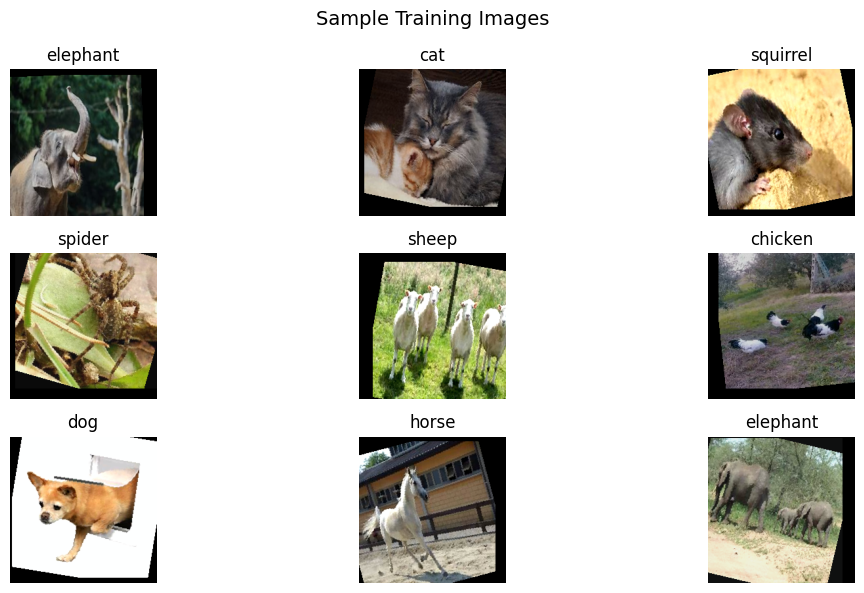

In [11]:
def imshow(img, title=''):
    img = img.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std  = np.array([0.229, 0.224, 0.225])
    img  = std * img + mean
    img  = np.clip(img, 0, 1)
    plt.imshow(img)
    plt.title(title)
    plt.axis('off')

images, labels = next(iter(train_loader))

plt.figure(figsize=(12, 6))
for i in range(9):
    plt.subplot(3, 3, i + 1)
    imshow(images[i], title=class_names[labels[i]])
plt.suptitle('Sample Training Images', fontsize=14)
plt.tight_layout()
plt.show()

In [13]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [14]:
model = models.efficientnet_b2(weights=models.EfficientNet_B2_Weights.DEFAULT)

# PHASE 1 — freeze all base layers
for param in model.parameters():
    param.requires_grad = False

in_features = model.classifier[1].in_features

model.classifier = nn.Sequential(
    nn.BatchNorm1d(in_features),
    nn.Linear(in_features, 256),
    nn.ReLU(),
    nn.Dropout(0.4),
    nn.Linear(256, NUM_CLASSES)
)

model = model.to(device)

print("Model ready!")
print(f"Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

Model ready!
Trainable parameters: 366,090


In [15]:
def train_model(model, train_loader, val_loader, optimizer, criterion, epochs, phase_name):

    train_acc_list = []
    val_acc_list   = []

    for epoch in range(epochs):
        model.train()
        correct = 0
        total   = 0
        running_loss = 0.0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss    = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted  = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total   += labels.size(0)

        train_acc = correct / total

        model.eval()
        correct = 0
        total   = 0

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                _, predicted = torch.max(outputs, 1)
                correct += (predicted == labels).sum().item()
                total   += labels.size(0)

        val_acc = correct / total

        train_acc_list.append(train_acc)
        val_acc_list.append(val_acc)

        print(f"[{phase_name}] Epoch {epoch+1}/{epochs}  "
              f"Loss: {running_loss/len(train_loader):.4f}  "
              f"Train Acc: {train_acc*100:.2f}%  "
              f"Val Acc: {val_acc*100:.2f}%")

    return train_acc_list, val_acc_list

In [17]:
criterion  = nn.CrossEntropyLoss()

optimizer1 = optim.Adam(model.classifier.parameters(), lr=PHASE1_LR)

print("=== PHASE 1: Training head only (base frozen) ===")
train_acc1, val_acc1 = train_model(
    model, train_loader, val_loader,
    optimizer1, criterion,
    epochs=PHASE1_EPOCHS,
    phase_name='Phase 1'
)

=== PHASE 1: Training head only (base frozen) ===
[Phase 1] Epoch 1/5  Loss: 0.3454  Train Acc: 89.41%  Val Acc: 94.35%
[Phase 1] Epoch 2/5  Loss: 0.2726  Train Acc: 91.63%  Val Acc: 94.73%
[Phase 1] Epoch 3/5  Loss: 0.2579  Train Acc: 91.91%  Val Acc: 95.00%
[Phase 1] Epoch 4/5  Loss: 0.2382  Train Acc: 92.29%  Val Acc: 95.36%
[Phase 1] Epoch 5/5  Loss: 0.2257  Train Acc: 92.75%  Val Acc: 94.88%


In [18]:
PHASE2_EPOCHS = 10
BATCH_SIZE    = 64

for param in model.parameters():
    param.requires_grad = False

for param in model.features[-3:].parameters():
    param.requires_grad = True

for param in model.classifier.parameters():
    param.requires_grad = True

optimizer2 = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=PHASE2_LR
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer2, mode='max', patience=3, factor=0.3
)

print("=== PHASE 2: Partial fine-tuning (last 3 blocks) ===")
print(f"Epochs: {PHASE2_EPOCHS}  |  LR: {PHASE2_LR}\n")

train_acc2, val_acc2 = train_model(
    model, train_loader, val_loader,
    optimizer2, criterion,
    epochs=PHASE2_EPOCHS,
    phase_name='Phase 2'
)

print(f"\nPhase 2 done! Best Val Acc: {max(val_acc2)*100:.2f}%")

=== PHASE 2: Partial fine-tuning (last 3 blocks) ===
Epochs: 10  |  LR: 0.0001

[Phase 2] Epoch 1/10  Loss: 0.1762  Train Acc: 94.42%  Val Acc: 96.93%
[Phase 2] Epoch 2/10  Loss: 0.1188  Train Acc: 96.33%  Val Acc: 97.38%
[Phase 2] Epoch 3/10  Loss: 0.0867  Train Acc: 97.19%  Val Acc: 97.29%
[Phase 2] Epoch 4/10  Loss: 0.0689  Train Acc: 97.82%  Val Acc: 97.69%
[Phase 2] Epoch 5/10  Loss: 0.0604  Train Acc: 98.02%  Val Acc: 97.44%
[Phase 2] Epoch 6/10  Loss: 0.0531  Train Acc: 98.28%  Val Acc: 97.50%
[Phase 2] Epoch 7/10  Loss: 0.0420  Train Acc: 98.62%  Val Acc: 97.63%
[Phase 2] Epoch 8/10  Loss: 0.0416  Train Acc: 98.56%  Val Acc: 97.61%
[Phase 2] Epoch 9/10  Loss: 0.0395  Train Acc: 98.66%  Val Acc: 97.73%
[Phase 2] Epoch 10/10  Loss: 0.0372  Train Acc: 98.85%  Val Acc: 97.71%

Phase 2 done! Best Val Acc: 97.73%


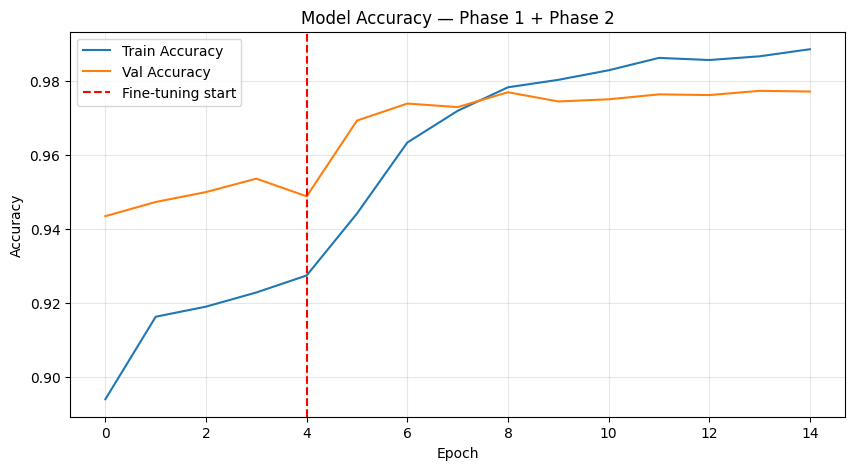

In [19]:
all_train_acc = train_acc1 + train_acc2
all_val_acc   = val_acc1   + val_acc2

plt.figure(figsize=(10, 5))

plt.plot(all_train_acc, label='Train Accuracy')
plt.plot(all_val_acc,   label='Val Accuracy')

plt.axvline(PHASE1_EPOCHS - 1, color='red', linestyle='--', label='Fine-tuning start')

plt.title('Model Accuracy — Phase 1 + Phase 2')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [20]:
model.eval()

y_true = []
y_pred = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        y_true.extend(labels.numpy())
        y_pred.extend(predicted.cpu().numpy())

accuracy  = np.mean(np.array(y_true) == np.array(y_pred))
precision = precision_score(y_true, y_pred, average='weighted')
f1        = f1_score(y_true, y_pred, average='weighted')

print(f"Validation Accuracy  : {accuracy*100:.2f}%")
print(f"Precision Score      : {precision:.4f}")
print(f"F1 Score             : {f1:.4f}")

Validation Accuracy  : 97.71%
Precision Score      : 0.9772
F1 Score             : 0.9771


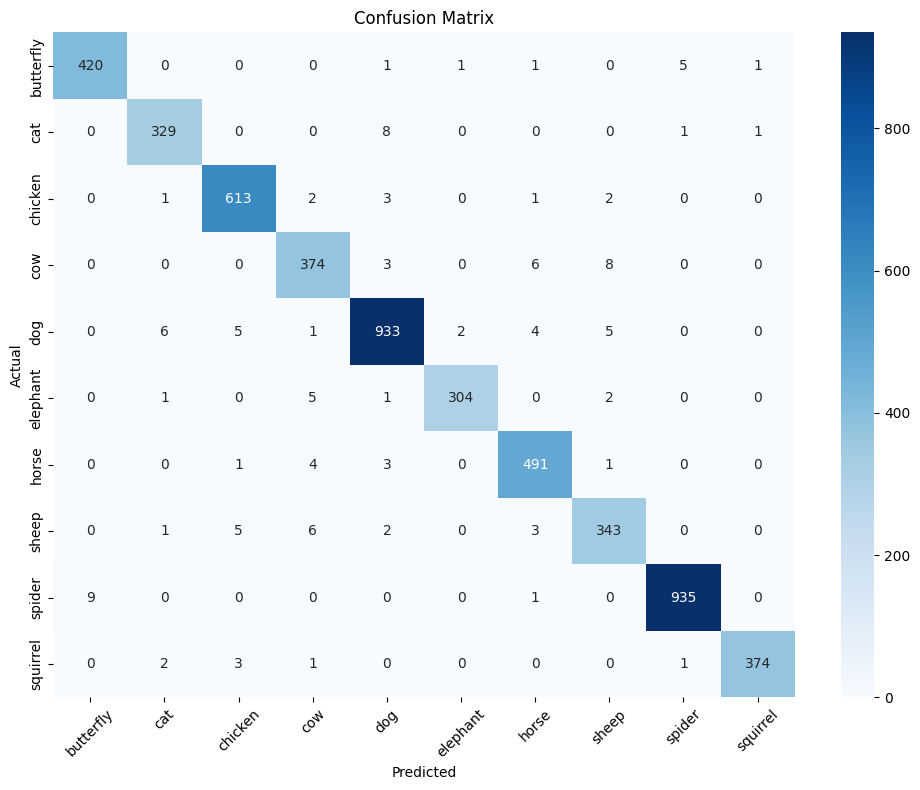

In [21]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [22]:
print(classification_report(y_true, y_pred, target_names=class_names))

              precision    recall  f1-score   support

   butterfly       0.98      0.98      0.98       429
         cat       0.97      0.97      0.97       339
     chicken       0.98      0.99      0.98       622
         cow       0.95      0.96      0.95       391
         dog       0.98      0.98      0.98       956
    elephant       0.99      0.97      0.98       313
       horse       0.97      0.98      0.98       500
       sheep       0.95      0.95      0.95       360
      spider       0.99      0.99      0.99       945
    squirrel       0.99      0.98      0.99       381

    accuracy                           0.98      5236
   macro avg       0.98      0.97      0.97      5236
weighted avg       0.98      0.98      0.98      5236



In [23]:
torch.save(model.state_dict(), 'animal_classifier.pth')
print("Model saved as animal_classifier.pth")

Model saved as animal_classifier.pth


In [24]:
from google.colab import files
files.download('animal_classifier.pth')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
model.load_state_dict(torch.load('animal_classifier.pth', map_location=device))
model.eval()
print("Model loaded successfully!")

In [25]:
from PIL import Image

def predict_image(image_path, model, class_names):

    img = Image.open(image_path).convert('RGB')

    transform = transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225])
    ])

    img_tensor = transform(img).unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        outputs = model(img_tensor)
        probabilities = torch.softmax(outputs, dim=1)[0]
        predicted_idx = torch.argmax(probabilities).item()

    plt.figure(figsize=(5, 5))
    plt.imshow(img)
    plt.title(f"Predicted: {class_names[predicted_idx]}\n"
              f"Confidence: {probabilities[predicted_idx]*100:.2f}%")
    plt.axis('off')
    plt.show()



In [26]:
import torch.quantization
import copy
import time

In [27]:
def get_model_size_mb(mdl):
    torch.save(mdl.state_dict(), 'tmp_model.pth')
    size = os.path.getsize('tmp_model.pth') / (1024 * 1024)
    os.remove('tmp_model.pth')
    return size

In [28]:
def evaluate_model(mdl, loader, device='cpu'):
    mdl.eval()
    correct = 0
    total = 0
    start = time.time()
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = mdl(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    elapsed = time.time() - start
    accuracy = 100 * correct / total
    return accuracy, elapsed

In [29]:
original_model = copy.deepcopy(model).to('cpu')
original_model.eval()

original_size = get_model_size_mb(original_model)
print(f"Original Model Size : {original_size:.2f} MB")

Original Model Size : 31.21 MB


In [30]:
quantized_model = torch.quantization.quantize_dynamic(
    original_model,
    {nn.Linear},
    dtype=torch.qint8
)

quantized_size = get_model_size_mb(quantized_model)
print(f"Quantized Model Size: {quantized_size:.2f} MB")
print(f"Size Reduction      : {((original_size - quantized_size) / original_size) * 100:.1f}%")

Quantized Model Size: 30.18 MB
Size Reduction      : 3.3%


/tmp/ipykernel_2639/1268780653.py:1: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.quantization.quantize_dynamic), please migrate to use torchao eager mode quantize_ API instead 
2. FX graph mode quantization (torch.ao.quantization.quantize_fx.prepare_fx,torch.ao.quantization.quantize_fx.convert_fx, please migrate to use torchao pt2e quantization API instead (prepare_pt2e, convert_pt2e) 
3. pt2e quantization has been migrated to torchao (https://github.com/pytorch/ao/tree/main/torchao/quantization/pt2e) 
see https://github.com/pytorch/ao/issues/2259 for more details
  quantized_model = torch.quantization.quantize_dynamic(


In [32]:
val_loader_cpu = DataLoader(val_dataset, batch_size=32, shuffle=False)

orig_acc, orig_time = evaluate_model(original_model, val_loader_cpu, device='cpu')
print(f"Original  — Accuracy: {orig_acc:.2f}%  |  Inference Time: {orig_time:.2f}s")

quant_acc, quant_time = evaluate_model(quantized_model, val_loader_cpu, device='cpu')
print(f"Quantized — Accuracy: {quant_acc:.2f}%  |  Inference Time: {quant_time:.2f}s")

KeyboardInterrupt: 

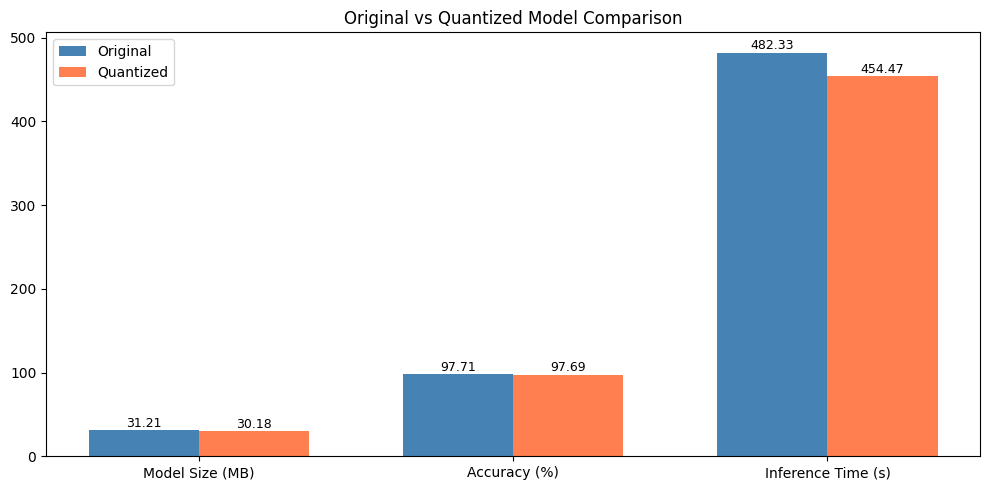

In [33]:
categories   = ['Model Size (MB)', 'Accuracy (%)', 'Inference Time (s)']
orig_vals    = [original_size,  orig_acc,  orig_time]
quant_vals   = [quantized_size, quant_acc, quant_time]

x = np.arange(len(categories))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - width/2, orig_vals,  width, label='Original',  color='steelblue')
bars2 = ax.bar(x + width/2, quant_vals, width, label='Quantized', color='coral')

ax.set_xticks(x)
ax.set_xticklabels(categories)
ax.set_title('Original vs Quantized Model Comparison')
ax.legend()

for bar in bars1 + bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

In [34]:
torch.save(quantized_model.state_dict(), 'animal_classifier_quantized.pth')
print("Quantized model saved as animal_classifier_quantized.pth")

Quantized model saved as animal_classifier_quantized.pth


In [35]:
def predict_image_quantized(image_path, mdl, class_names):
    from PIL import Image
    img = Image.open(image_path).convert('RGB')

    transform = transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225])
    ])

    img_tensor = transform(img).unsqueeze(0)

    mdl.eval()
    with torch.no_grad():
        outputs = mdl(img_tensor)
        probabilities = torch.softmax(outputs, dim=1)[0]
        predicted_idx = torch.argmax(probabilities).item()

    plt.figure(figsize=(5, 5))
    plt.imshow(img)
    plt.title(f"Predicted: {class_names[predicted_idx]}\nConfidence: {probabilities[predicted_idx]*100:.2f}%")
    plt.axis('off')
    plt.show()